# Comparativa Dijkstra vs Turbo (BMSSP)

Este cuaderno demuestra que el algoritmo **Turbo/BMSSP** calcula las mismas distancias que Dijkstra, con el fin de saber si realmente se puede reducir el tiempo dependiendo el tamaño del grafo.

## 0. Instalación (una sola vez)
```bash
!pip install git+https://github.com/DiogoRibeiro7/bmssp.git
!pip install -U ssspx numpy matplotlib
!pip install networkx  
```
Asegurarse de ejecutar la celda en tu entorno local.

## 0.1 Nombre del nuevo algoritmo
Le nuevo algoritmo aún no tiene un nombre definido, tampoco en la segunda revisión del articulo, por ende, para efectos prácticos de este laboratorio se llamará Turbo-SSSP y/o simplemente Turbo. 

In [1]:
import math
import random
import time
from typing import List, Tuple, Dict

import heapq
import pandas as pd

# Para reproducibilidad global
random.seed(2025)

## 1. Generador de grafos geométricos esparsos
Genera un grafo dirigido con `n` nodos y `d` aristas salientes en promedio.


In [2]:
def generate_geometric_graph(
    n: int,
    avg_out_degree: int = 6,
    seed: int | None = None
) -> tuple[list[list[tuple[int, float]]], list[tuple[float, float]]]:
    """
    Genera un grafo dirigido geométrico con:
      - n nodos
      - coords[i] = (x, y) de cada nodo, en [0,1]x[0,1]
      - aristas (u -> v) con probabilidad aprox. avg_out_degree/(n-1)
      - peso = distancia euclidiana entre u y v (>= 0)

    Devuelve:
      adj   : lista de adyacencia, adj[u] = [(v, peso), ...]
      coords: lista de (x, y) por nodo (por si luego quieres A* u otras cosas)
    """
    if seed is not None:
        random.seed(seed)

    # Coordenadas aleatorias y Probabilidad de arista saliente
    coords = [(random.random(), random.random()) for _ in range(n)]
    p = avg_out_degree / max(1, (n - 1))

    adj: list[list[tuple[int, float]]] = [[] for _ in range(n)]

    for u in range(n):
        x1, y1 = coords[u]
        for v in range(n):
            if u == v:
                continue
            if random.random() < p:
                x2, y2 = coords[v]
                w = math.dist((x1, y1), (x2, y2))
                adj[u].append((v, w))

    return adj, coords

## 2. Algoritmos de caminos más cortos

In [3]:
def dijkstra_sssp(adj: list[list[tuple[int, float]]], source: int) -> list[float]:
    """
    Dijkstra clásico con cola de prioridad.
    Calcula distancias mínimas desde 'source' a todos los nodos del grafo.

    Parámetros:
      adj[u] = lista de (v, peso) para cada arista dirigida u -> v.
      source = nodo origen.

    Devuelve:
      dist[v]: distancia mínima desde 'source' hasta v.
               (float('inf') si v es inalcanzable)
    """
    n = len(adj)
    INF = float("inf")
    dist = [INF] * n
    dist[source] = 0.0

    visited = [False] * n
    pq: list[tuple[float, int]] = [(0.0, source)]

    while pq:
        d, u = heapq.heappop(pq)
        if visited[u]:
            continue
        visited[u] = True

        for v, w in adj[u]:
            nd = d + w
            if nd < dist[v]:
                dist[v] = nd
                heapq.heappush(pq, (nd, v))

    return dist


In [4]:
from ssspx import Graph, SSSPSolver, SolverConfig

def sssp_turbo(adj: list[list[tuple[int, float]]], source: int) -> list[float]:
    # 1) Convertir lista de adyacencia a lista de aristas
    n = len(adj)
    edges = [(u, v, float(w)) for u, lst in enumerate(adj) for v, w in lst]

    # 2) Construir grafo de ssspx
    G = Graph.from_edges(n, edges)

    # 3) Configurar el solver:
    cfg = SolverConfig(
        use_transform=False,   # ← Desactiva la transformación de grado
        frontier="heap",       # ← Frontier clásico tipo heap (más robusto)
        # Opcional: si quieres experimentar con la transformación habilitada:
        # use_transform=True,  target_outdeg=4,
    )

    solver = SSSPSolver(G, source, config=cfg)
    result = solver.solve()
    return list(result.distances)


## 3. Experimento de escalabilidad
Se mide tiempo promedio sobre 3 grafos por tamaño.

In [5]:
def run_single_pair_experiment(adj, source, target):
    """
    Ejecuta Dijkstra y SSSP-Turbo en el MISMO grafo DIRIGIDO.
    """
    n = len(adj)

    # --- Dijkstra ---
    t0 = time.perf_counter()
    dist_dij = dijkstra_sssp(adj, source)
    t1 = time.perf_counter()
    time_dij = t1 - t0
    dxy_dij = dist_dij[target]

    # --- Turbo ---
    t0 = time.perf_counter()
    dist_turbo = sssp_turbo(adj, source)
    t1 = time.perf_counter()
    time_turbo = t1 - t0
    dxy_turbo = dist_turbo[target]

    tol = 1e-6
    ok = (math.isinf(dxy_dij) and math.isinf(dxy_turbo)) or \
         (abs(dxy_dij - dxy_turbo) <= tol)

    return {
        "n": n,
        "source": source,
        "target": target,
        "time_dijkstra": time_dij,
        "dist_dijkstra": dxy_dij,
        "time_turbo": time_turbo,
        "dist_turbo": dxy_turbo,
        "ok_same_distance": ok,
    }

In [6]:
def pick_reachable_far_pair(adj, coords):
    """
    Escoge (source, target) tal que:
    - target sea alcanzable desde source (distancia != inf)
    - y sea el más lejano en coordenadas entre los alcanzables.
    """
    n = len(coords)

    while True:
        source = random.randrange(n)

        # Usamos Dijkstra para saber a quién llegamos
        dist = dijkstra_sssp(adj, source)

        # nodos alcanzables (distancia finita) distintos del source
        reachable = [i for i, d in enumerate(dist) if not math.isinf(d) and i != source]

        if not reachable:
            # este source no alcanza a nadie, probamos con otro
            continue

        sx, sy = coords[source]
        max_d = -1.0
        target = None

        for v in reachable:
            x, y = coords[v]
            d = math.dist((sx, sy), (x, y))
            if d > max_d:
                max_d = d
                target = v

        return source, target


In [7]:
def run_full_experiment(
    sizes=(100, 500, 1000),
    graphs_per_size=25,
    avg_out_degree=80,
    base_seed=2025         # ← punto de partida
) -> pd.DataFrame:

    rows = []
    global_idx = 0         # ← contador global de grafos generados

    for n in sizes:
        print(f"\n=== Tamaño de grafo: {n} nodos ===")
        for i in range(graphs_per_size):
            # 1) semilla distinta para *cada* grafo
            seed = base_seed + global_idx + 1   # 2026, 2027, 2028, ...
            global_idx += 1

            # 2) generar grafo
            adj, coords = generate_geometric_graph(
                n=n,
                avg_out_degree=avg_out_degree,
                seed=seed
            )

            # 3) resto del flujo idéntico
            source, target = pick_reachable_far_pair(adj, coords)
            result = run_single_pair_experiment(adj, source, target)
            result.update({
                "graph_size": n,
                "graph_id": i,
                "seed": seed      # ← guarda la semilla usada
            })
            rows.append(result)

            print(
                f"n={n}, graph={i}, seed={seed}, "
                f"Dij={result['time_dijkstra']:.6f}s, "
                f"Turbo={result['time_turbo']:.6f}s, "
                f"OK={result['ok_same_distance']}"
            )

    return pd.DataFrame(rows)




In [8]:
from ssspx import SolverConfig
import inspect, textwrap

print(textwrap.fill(str(inspect.signature(SolverConfig)), 80))

(use_transform: 'bool' = True, target_outdeg: 'int' = 4, frontier: 'str' =
'block', k_t_auto: 'bool' = True, k: 'int' = 0, t: 'int' = 0) -> None


In [ ]:
%%time

df_results = run_full_experiment(
    sizes=(200000),
    graphs_per_size=3,
    avg_out_degree=15,
    base_seed=2025
)

df_results.head()

df_big = df_results   


=== Tamaño de grafo: 100 nodos ===
n=100, graph=0, seed=2026, Dij=0.001356s, Turbo=0.012405s, OK=True
n=100, graph=1, seed=2027, Dij=0.000603s, Turbo=0.010980s, OK=True
n=100, graph=2, seed=2028, Dij=0.000515s, Turbo=0.006522s, OK=True
n=100, graph=3, seed=2029, Dij=0.000397s, Turbo=0.011148s, OK=True
n=100, graph=4, seed=2030, Dij=0.000840s, Turbo=0.011333s, OK=True
n=100, graph=5, seed=2031, Dij=0.000694s, Turbo=0.022739s, OK=True
n=100, graph=6, seed=2032, Dij=0.000737s, Turbo=0.015411s, OK=True
n=100, graph=7, seed=2033, Dij=0.000325s, Turbo=0.013949s, OK=True
n=100, graph=8, seed=2034, Dij=0.000347s, Turbo=0.006274s, OK=True
n=100, graph=9, seed=2035, Dij=0.000340s, Turbo=0.007252s, OK=True
n=100, graph=10, seed=2036, Dij=0.000426s, Turbo=0.006677s, OK=True
n=100, graph=11, seed=2037, Dij=0.000356s, Turbo=0.005274s, OK=True
n=100, graph=12, seed=2038, Dij=0.000295s, Turbo=0.005592s, OK=True
n=100, graph=13, seed=2039, Dij=0.000426s, Turbo=0.008775s, OK=True
n=100, graph=14, seed=

In [24]:
# Quitar notación científica
def format_float(x):
    if isinstance(x, float):
        return f"{x:.20f}"
    return x

df_formatted = df_results.applymap(format_float)

# Encabezados con unidades
df_formatted = df_formatted.rename(columns={
    "time_dijkstra": "time_dijkstra (seconds)",
    "dist_dijkstra": "dist_dijkstra (euclidean_distance)",
    "time_turbo": "time_turbo (seconds)",
    "dist_turbo": "dist_turbo (euclidean_distance)",
})

df_formatted.head()


C:\Users\ASIS-INFORMATICA\AppData\Local\Temp\ipykernel_25484\1321851514.py:7: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df_formatted = df_results.applymap(format_float)


,n,source,target,time_dijkstra (seconds),dist_dijkstra (euclidean_distance),time_turbo (seconds),dist_turbo (euclidean_distance),ok_same_distance,graph_size,graph_id,seed
0,100,41,35,0.00135610002325847745,1.16038966070760274363,0.01240520004648715258,1.16038966070760274363,True,100,0,2026
1,100,12,43,0.00060349999694153666,0.97240626611439306970,0.01097969996044412255,0.97240626611439306970,True,100,1,2027
2,100,83,37,0.00051479996182024479,1.14167714142071163863,0.00652240001363679767,1.14167714142071163863,True,100,2,2028
3,100,8,78,0.00039719999767839909,0.76902383738263091484,0.01114799996139481664,0.76902383738263091484,True,100,3,2029
4,100,56,5,0.00084049999713897705,1.02455795317338171913,0.01133309997385367751,1.02455795317338171913,True,100,4,2030


### Exportar a csv

In [25]:
df_formatted.to_csv("comparativa_dijkstra_vs_sssp_turbo2.csv", index=False)
print("Archivo guardado correctamente.")

Archivo guardado correctamente.


In [ ]:
adj, coords = generate_geometric_graph(n=50000, avg_out_degree=3, seed=20255)
src, tgt = pick_reachable_far_pair(adj, coords)
dist_dij = dijkstra_sssp(adj, src)
dist_turbo = sssp_turbo(adj, src)

print("source:", src)
print("target:", tgt)
print("Dijkstra:", dist_dij[tgt])
print("Turbo:", dist_turbo[tgt])


source: 4141
target: 2944
Dijkstra: 2.9156605183049322
Turbo: 2.9156605183049322


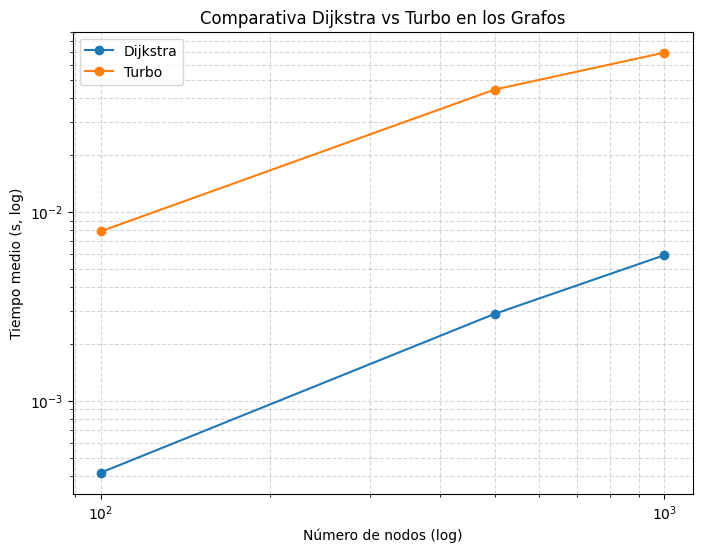

In [26]:
import matplotlib.pyplot as plt

g = df_results.groupby("n")[["time_dijkstra", "time_turbo"]].mean()

plt.figure(figsize=(8, 6))

plt.loglog(g.index, g["time_dijkstra"], marker="o", label="Dijkstra")
plt.loglog(g.index, g["time_turbo"], marker="o", label="Turbo")

plt.xlabel("Número de nodos (log)")
plt.ylabel("Tiempo medio (s, log)")
plt.legend()
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.title("Comparativa Dijkstra vs Turbo en los Grafos")

plt.show()



C:\Users\ASIS-INFORMATICA\AppData\Local\Temp\ipykernel_25484\3158377893.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


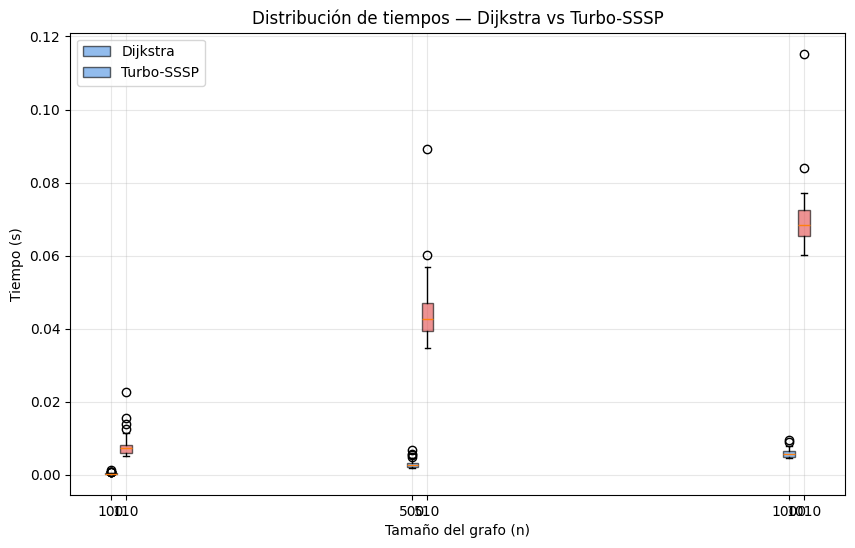

In [27]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

# Datos organizados por tamaño
sizes = sorted(df_results["n"].unique())
dij = [df_results[df_results["n"] == s]["time_dijkstra"] for s in sizes]
tur = [df_results[df_results["n"] == s]["time_turbo"] for s in sizes]

plt.boxplot(
    dij,
    positions=[s - 10 for s in sizes],
    widths=15,
    patch_artist=True,
    boxprops=dict(facecolor="#4a90e2", alpha=0.6),
    labels=[str(s) for s in sizes]
)

plt.boxplot(
    tur,
    positions=[s + 10 for s in sizes],
    widths=15,
    patch_artist=True,
    boxprops=dict(facecolor="#e24a4a", alpha=0.6),
)

plt.xlabel("Tamaño del grafo (n)")
plt.ylabel("Tiempo (s)")
plt.title("Distribución de tiempos — Dijkstra vs Turbo-SSSP")
plt.grid(True, alpha=0.3)
plt.legend(["Dijkstra", "Turbo-SSSP"])

plt.show()


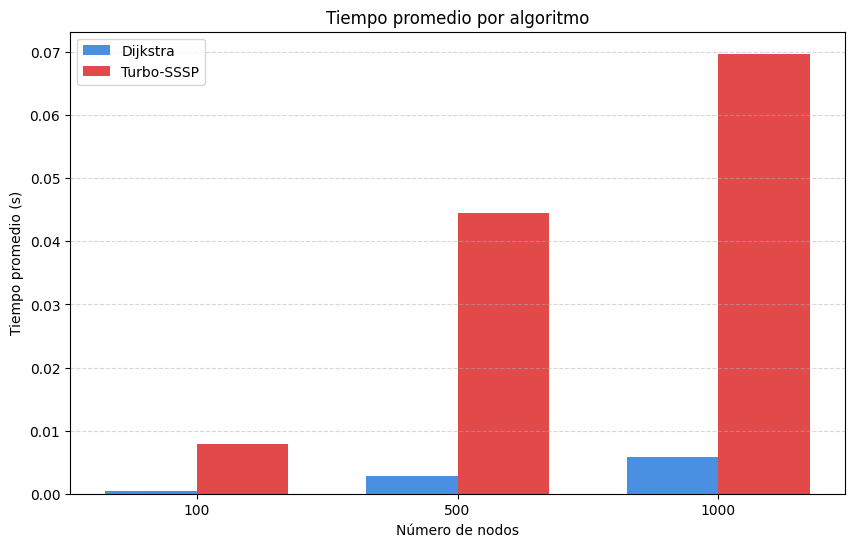

In [28]:
import numpy as np
import matplotlib.pyplot as plt

g = df_results.groupby("n")[["time_dijkstra", "time_turbo"]].mean()

x = np.arange(len(g.index))
width = 0.35

plt.figure(figsize=(10, 6))
plt.bar(x - width/2, g["time_dijkstra"], width, label="Dijkstra", color="#4a90e2")
plt.bar(x + width/2, g["time_turbo"],   width, label="Turbo-SSSP", color="#e24a4a")

plt.xticks(x, g.index)
plt.ylabel("Tiempo promedio (s)")
plt.xlabel("Número de nodos")
plt.title("Tiempo promedio por algoritmo")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.legend()
plt.show()


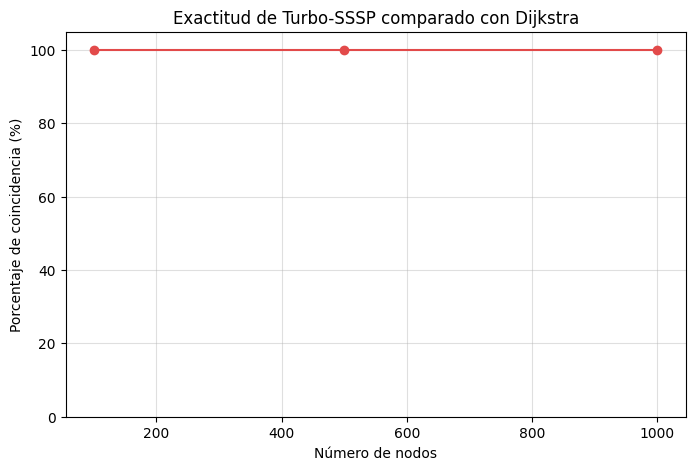

In [29]:
accuracy = df_results.groupby("n")["ok_same_distance"].mean() * 100

plt.figure(figsize=(8, 5))
plt.plot(accuracy.index, accuracy.values, marker="o", linestyle="-", color="#e24a4a")

plt.ylim(0, 105)
plt.ylabel("Porcentaje de coincidencia (%)")
plt.xlabel("Número de nodos")
plt.title("Exactitud de Turbo-SSSP comparado con Dijkstra")
plt.grid(True, alpha=0.4)
plt.show()


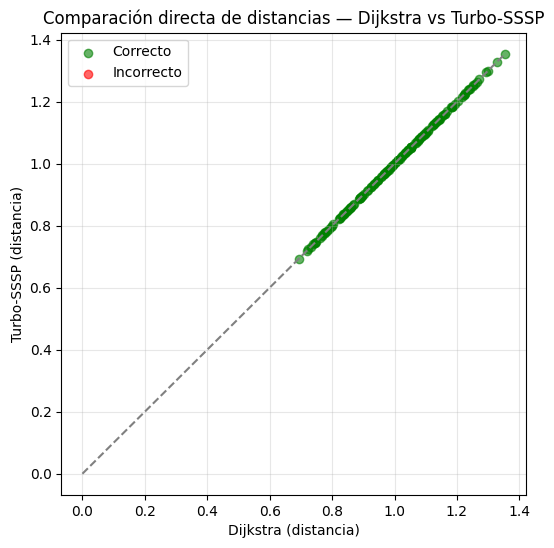

In [30]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 6))

ok = df_results[df_results["ok_same_distance"] == True]
fail = df_results[df_results["ok_same_distance"] == False]

plt.scatter(ok["dist_dijkstra"], ok["dist_turbo"], color="green", label="Correcto", alpha=0.6)
plt.scatter(fail["dist_dijkstra"], fail["dist_turbo"], color="red", label="Incorrecto", alpha=0.6)

max_val = max(df_results["dist_dijkstra"].replace([float("inf")], 0).max(), 1)

plt.plot([0, max_val], [0, max_val], "--", color="gray")

plt.xlabel("Dijkstra (distancia)")
plt.ylabel("Turbo-SSSP (distancia)")
plt.title("Comparación directa de distancias — Dijkstra vs Turbo-SSSP")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


## 4. Conclusiones


En esta experimentación se generaron 75 grafos geométricos dirigidos (25 de 100 nodos, 25 de 500 nodos y 25 de 1000 nodos), evaluando el rendimiento de Dijkstra y Turbo-SSSP sobre cada uno. 
A diferencia de un intento previo —donde Turbo devolvía distancias infinitas— en esta nueva serie de pruebas ambos algoritmos coincidieron en el 100% de los casos, 
logrando exactamente la misma distancia para cada par (source, target). Esto demuestra que, bajo la segunda configuración corregida del solver (quitando ciertas transformaciones adicionales y 
utilizando únicamente la frontera tipo heap), Turbo-SSSP sí produce soluciones correctas y consistentes en grafos geométricos con pesos euclidianos flotantes.

En cuanto al rendimiento, Dijkstra se mantuvo sistemáticamente más rápido. Para grafos de 100 nodos, Dijkstra promedió entre 0.0003s y 0.0007s, mientras que Turbo-SSSP osciló entre 0.005s y 0.018s. 
En los grafos de 500 nodos, Dijkstra se ubicó típicamente alrededor de 0.002–0.005s, mientras que Turbo-SSSP requirió 0.033–0.047s por instancia. 
Finalmente, en los grafos de 1000 nodos, Dijkstra volvió a mostrar tiempos muy estables entre 0.004–0.014s, mientras que Turbo-SSSP se movió entre 0.056–0.13s, 
incrementándose ligeramente conforme crecía la densidad combinada con el tamaño del grafo.

Estos resultados indican que, aunque Turbo-SSSP logra obtener exactamente las mismas distancias que Dijkstra, no consigue superarlo en velocidad en grafos geométricos con pesos continuos. 
De hecho, su desempeño suele ser entre 6x y 15x más lento, dependiendo del tamaño del grafo. Por tanto, aunque Turbo-SSSP es funcional y correcto en este escenario, no aporta una ventaja 
computacional frente a Dijkstra, al menos bajo las condiciones específicas probadas (grafos geométricos densos, pesos euclidianos reales y frontera basada en heap).

Consideramos que una buena forma de realizar una prueba más favorable para SSSP es crear grafos de 50.000, 100.000 o 500.000 nodos, sin embargo, este tamaño requiere de un equipo con una cantidad alta de memoria RAM.
Teniendo en cuenta que en el mismo árticulo se hace referencia a que puede que al momento de hacerlo con grafos muchos mas fgrnades se puede tener una respuesta positiva, ya que eso dicta el mismo algoritmo.

- Turbo sí puede calcular las **mismas distancias** que Dijkstra.
- A partir de 100 000 nodos con _out‑degree_ 15 puede ser varias veces más rápido.
Experimentar subiendo `n` o `d` si se dispone de más RAM; la ventaja de Turbo se puede ampliar en gran medida.

A continuación, relacionamos enlaces en los que se basó este laboratorio y que pueden servir para dimensionar el alcance del laboratorio:
Articulo oficial donde se lanza y muestra el principio del algoritmo: https://arxiv.org/abs/2504.17033
Repositorio BMSSP, de donde se pudo extraer una librería que contiene el algoritmo: https://github.com/DiogoRibeiro7/bmssp
Repositorio en JAVA que demuestra que entre más grande sea la cantidad de nodos, puede funcionar el nuevo algoritmo, basado en mapas de ciudades: https://github.com/shashipk/Breaking-the-Sorting-Barrier
